In [1]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

heart_disease.variables

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,None,years,no
1,sex,Feature,Categorical,Sex,None,None,no
2,cp,Feature,Categorical,None,None,None,no
3,trestbps,Feature,Integer,None,resting blood pressure (on admission to the ho...,mm Hg,no
4,chol,Feature,Integer,None,serum cholestoral,mg/dl,no
5,fbs,Feature,Categorical,None,fasting blood sugar > 120 mg/dl,None,no
6,restecg,Feature,Categorical,None,None,None,no
7,thalach,Feature,Integer,None,maximum heart rate achieved,None,no
8,exang,Feature,Categorical,None,exercise induced angina,None,no
9,oldpeak,Feature,Integer,None,ST depression induced by exercise relative to ...,None,no


In [2]:
dados = heart_disease.data.features
dados.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


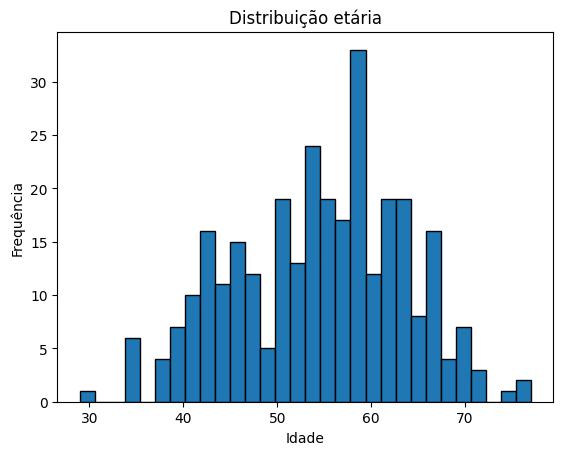

In [3]:
import matplotlib.pyplot as plt

plt.hist(dados["age"], bins=30, edgecolor="black")
plt.title("Distribuição etária")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

In [4]:
heart_disease.data.targets

,num
0,0
1,2
2,1
3,0
4,0
...,...
298,1
299,2
300,3
301,1


In [5]:
heart_disease.data.targets > 0

,num
0,False
1,True
2,True
3,False
4,False
...,...
298,True
299,True
300,True
301,True


In [6]:
1 * (heart_disease.data.targets > 0)

,num
0,0
1,1
2,1
3,0
4,0
...,...
298,1
299,1
300,1
301,1


In [7]:
dados["doenca"] = 1 * (heart_disease.data.targets > 0)
dados.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,doenca
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


# Analisando distribuição das idades com Seaborn

<Axes: xlabel='doenca', ylabel='age'>

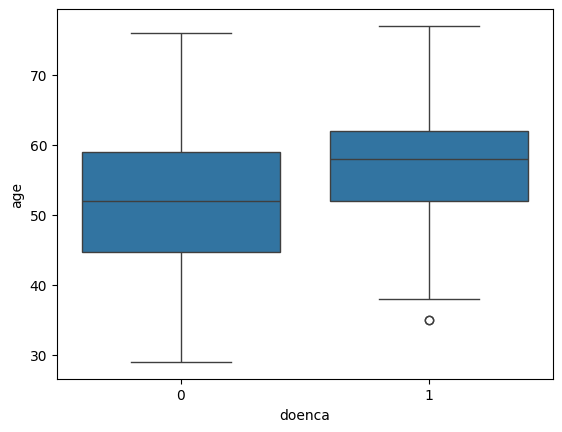

In [8]:
import seaborn as sns
sns.boxplot(y="age", x="doenca", data=dados)

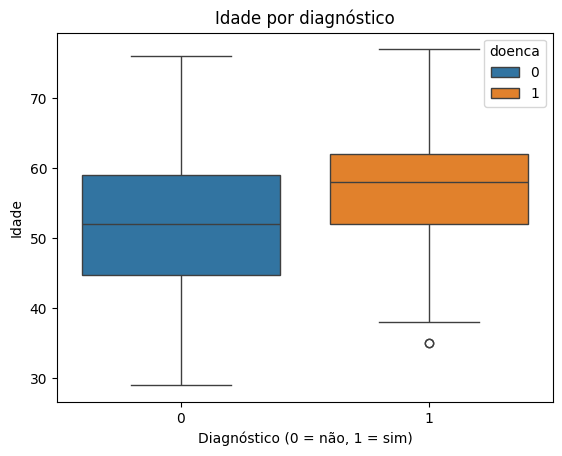

In [9]:
import seaborn as sns

sns.boxplot(y="age",x="doenca", data=dados, hue="doenca")
plt.title("Idade por diagnóstico")
plt.xlabel("Diagnóstico (0 = não, 1 = sim)")
plt.ylabel("Idade")
plt.show()

# Criando gráficos interativos

In [10]:
# histograma da idade usando Plotly Express

import plotly.express as px

fig = px.histogram(dados, x="age", nbins=30)

fig.update_layout(
    title="Distribuição etária",
    xaxis_title="Idade",
    yaxis_title="Frequência",
)

# Exiba o gráfico
fig.show()